### 24RB1075 小嶋将太郎

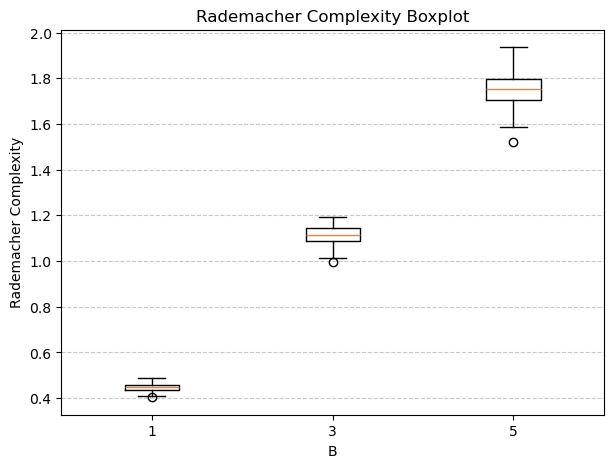

In [28]:
import numpy as np
import matplotlib.pyplot as plt

'パラメータの設定'
m = 10 
num_h = 16
num_sigma = 1000 
num_trials = 100
B_values = [1, 3, 5]

'Wを構成する関数'
def create_W(B, m = 10, num = 16):
    return np.random.randint(-B, B + 1, size =(num, m))

'Rademacher複雑度を計算する関数'
def rademacher(W, num_sigma):
    d = W.shape[1]
    sigma = np.random.choice([-1, 1], size =(num_sigma, d))
    scores = sigma @ W.T
    max_scores = np.max(scores, axis = 1)
    return np.mean(max_scores) / d

'各Bに対してRademacher複雑度を計算'
all_complexities = []

for B in B_values:
    complexities = []
    for _ in range(num_trials):
        W = create_W(B, m, num_h)
        complexity = rademacher(W, num_sigma)
        complexities.append(complexity)

    all_complexities.append(complexities)

'箱ひげ図の作成'
plt.figure(figsize=(7, 5))
plt.boxplot(all_complexities, tick_labels = B_values)
plt.xlabel('B')
plt.ylabel('Rademacher Complexity')
plt.title('Rademacher Complexity Boxplot')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
    

### 考察
各Bについて、複数の仮説集合Wをランダム生成し、Rademacher複雑度を計算した。結果として、Bを大きくすると複雑度は増加するという関係性を確認できた。これは、Bが大きいほど重みベクトルの取り得る範囲が広がり、モデルが多様な関数を表現できるようになるためである。また、箱ひげ図を見るとBの値を増やしていくほど複雑度のばらつきが大きくなる傾向が見られた。

### AIの使用
AIは、Rademacher複雑度を計算するプログラムの作成時に利用した。特に、複雑な定義式の実装手順を部分的に参考にした。また、ランダム生成に用いる関数やグラフ作成に用いる関数の解釈に役立てた。